     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.4/787.4 kB 45.8 MB/s eta 0:00:00
Created 120 tiles
Images: 120
Masks:  

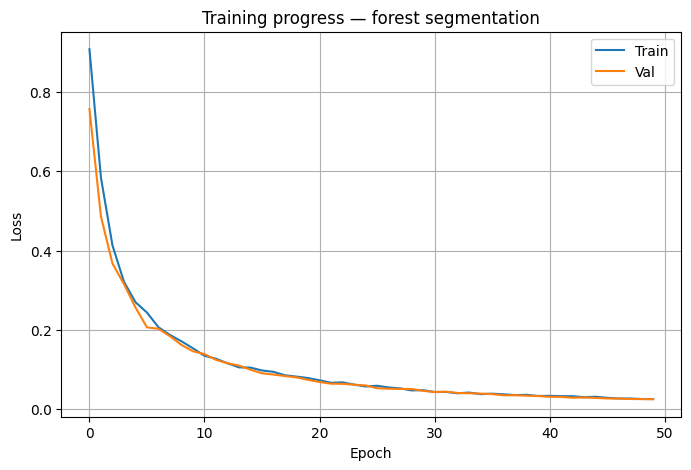

Training complete. Best val loss: 0.0253
Test Results:
  IoU:       0.9930
  Precision: 0.9981
  Recall:    0.9949


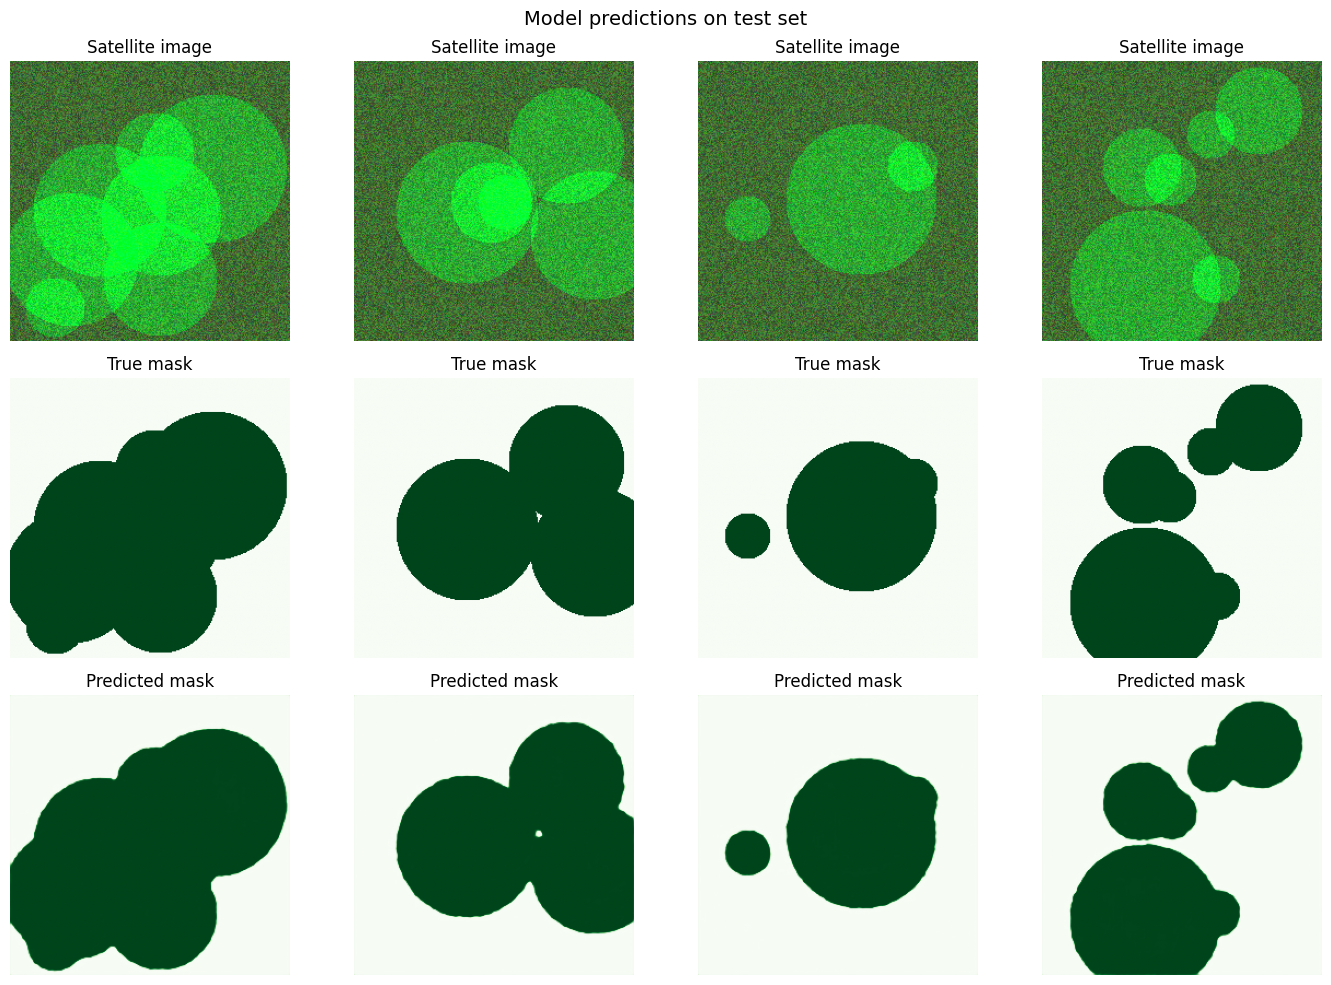

app.py written!
To run the API:  !uvicorn app:app --host 0.0.0.0 --port 8000 --reload
dashboard.py written!
To run the dashboard: !streamlit run dashboard.py
Docker files written:
  Dockerfile
  Dockerfile.dashboard
  docker-compose.yml
  requirements.txt
  monitoring/prometheus.yml

To build and run locally:
  docker-compose up --build
CI/CD pipeline written to .github/workflows/ci_cd.yml
Deployment script written to scripts/deploy_to_hf.py
Steps to deploy:
  1. Create a free account at huggingface.co
  2. Get your token from: huggingface.co/settings/tokens
  3. Replace YOUR_HF_USERNAME in the script
  4. Run: HF_TOKEN=your_token python scripts/deploy_to_hf.py
Drift monitor ready.


In [4]:
#

# =============================================================================
# CELL 1 — INSTALL ALL LIBRARIES (run this first, then restart runtime)
# =============================================================================
!pip install segmentation-models-pytorch mlflow albumentations \
             fastapi uvicorn python-multipart streamlit folium \
              streamlit-folium dvc gdown torchgeo prometheus-client \
              pydantic pillow opencv-python-headless -q


# =============================================================================
# CELL 2 — WEEK 1: CREATE SYNTHETIC TRAINING DATA
# =============================================================================

import os
import numpy as np
from PIL import Image

os.makedirs("data/images", exist_ok=True)
os.makedirs("data/masks",  exist_ok=True)

def make_forest_tile(idx, size=256):
    np.random.seed(idx)

    r = np.clip(np.random.randint(30,  100, (size, size)), 0, 255).astype(np.uint8)
    g = np.clip(np.random.randint(60,  160, (size, size)), 0, 255).astype(np.uint8)
    b = np.clip(np.random.randint(20,   80, (size, size)), 0, 255).astype(np.uint8)
    image = np.stack([r, g, b], axis=2).astype(np.int32)

    mask = np.zeros((size, size), dtype=np.uint8)
    for _ in range(np.random.randint(3, 8)):
        cx  = np.random.randint(30, size - 30)
        cy  = np.random.randint(30, size - 30)
        rad = np.random.randint(20, 70)
        yy, xx = np.ogrid[:size, :size]
        circle = (xx - cx)**2 + (yy - cy)**2 < rad**2
        mask[circle] = 255
        image[:, :, 1] = np.where(circle, np.clip(image[:, :, 1] + 60, 0, 255), image[:, :, 1])
        image[:, :, 0] = np.where(circle, np.clip(image[:, :, 0] - 20, 0, 255), image[:, :, 0])

    return image.astype(np.uint8), mask

NUM_TILES = 120
for i in range(NUM_TILES):
    img, mask = make_forest_tile(i)
    name = f"tile_{i:04d}.png"
    Image.fromarray(img).save(f"data/images/{name}")
    Image.fromarray(mask).save(f"data/masks/{name}")

print(f"Created {NUM_TILES} tiles")
print(f"Images: {len(os.listdir('data/images'))}")
print(f"Masks:  {len(os.listdir('data/masks'))}")


# =============================================================================
# MODEL DEFINITION
# =============================================================================

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

def get_model():
    """U-Net with pretrained ResNet34 encoder."""
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )

class CombinedLoss(nn.Module):
    """BCE + Dice loss — penalises missed forest pixels harder than plain BCE."""
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred, target, smooth=1.0):
        pred      = torch.sigmoid(pred)
        pred_flat = pred.view(-1)
        true_flat = target.view(-1)
        intersection = (pred_flat * true_flat).sum()
        return 1 - (2 * intersection + smooth) / (
            pred_flat.sum() + true_flat.sum() + smooth
        )

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)

print("Model and loss defined.")


# =============================================================================
# DATASET WITH AUGMENTATION
# =============================================================================

import cv2
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_transforms(is_train=True):
    if is_train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.Resize(256, 256),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    return A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

class ForestDataset(Dataset):
    def __init__(self, image_dir, mask_dir, is_train=True):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.images    = sorted(os.listdir(image_dir))
        self.transform = get_transforms(is_train)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir,  self.images[idx])

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, 0)
        mask  = (mask > 127).astype(np.float32)

        aug   = self.transform(image=image, mask=mask)
        return aug["image"], aug["mask"].unsqueeze(0)

print("Dataset defined.")


# =============================================================================
# TRAIN / VAL / TEST SPLIT
# =============================================================================

import shutil
import random

random.seed(42)

for split in ["train", "val", "test"]:
    os.makedirs(f"data/{split}/images", exist_ok=True)
    os.makedirs(f"data/{split}/masks",  exist_ok=True)

all_tiles = sorted(os.listdir("data/images"))
random.shuffle(all_tiles)

n         = len(all_tiles)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

splits = {
    "train": all_tiles[:train_end],
    "val":   all_tiles[train_end:val_end],
    "test":  all_tiles[val_end:]
}

for split, files in splits.items():
    for fname in files:
        shutil.copy(f"data/images/{fname}", f"data/{split}/images/{fname}")
        shutil.copy(f"data/masks/{fname}",  f"data/{split}/masks/{fname}")

print(f"Train: {len(splits['train'])} tiles")
print(f"Val:   {len(splits['val'])} tiles")
print(f"Test:  {len(splits['test'])} tiles")


# =============================================================================
# TRAIN THE MODEL
# =============================================================================

import mlflow
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)
os.makedirs("models",  exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {DEVICE}")

train_dataset = ForestDataset("data/train/images", "data/train/masks", is_train=True)
val_dataset   = ForestDataset("data/val/images",   "data/val/masks",   is_train=False)
train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=4, shuffle=False)

model     = get_model().to(DEVICE)
criterion = CombinedLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

NUM_EPOCHS    = 50
best_val_loss = float("inf")
train_losses, val_losses = [], []

mlflow.set_experiment("forest_segmentation")

with mlflow.start_run():
    mlflow.log_params({"encoder": "resnet34", "loss": "bce+dice",
                       "epochs": NUM_EPOCHS, "batch_size": 4, "lr": 1e-4})

    for epoch in range(NUM_EPOCHS):
        # -- Train
        model.train()
        train_loss = 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # -- Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                val_loss += criterion(model(imgs), masks).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        mlflow.log_metrics({"train_loss": train_loss, "val_loss": val_loss}, step=epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                  f"Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "models/best_model.pth")
            print(f"  -> Best model saved (val={best_val_loss:.4f})")

    mlflow.log_artifact("models/best_model.pth")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses,   label="Val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training progress — forest segmentation")
plt.legend(); plt.grid(True)
plt.savefig("outputs/loss_curve.png")
plt.show()
print(f"Training complete. Best val loss: {best_val_loss:.4f}")


# =============================================================================
# EVALUATE ON TEST SET (IoU, Precision, Recall)
# =============================================================================

test_dataset = ForestDataset("data/test/images", "data/test/masks", is_train=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

model.load_state_dict(torch.load("models/best_model.pth", map_location=DEVICE))
model.eval()

def calculate_metrics(pred_mask, true_mask, threshold=0.5):
    pred_bin = (pred_mask >= threshold).astype(np.uint8)
    true_bin = (true_mask >= threshold).astype(np.uint8)
    tp = (pred_bin & true_bin).sum()
    fp = (pred_bin & ~true_bin.astype(bool)).sum()
    fn = (~pred_bin.astype(bool) & true_bin).sum()
    union = (pred_bin | true_bin).sum()
    iou       = tp / (union + 1e-6)
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    return iou, precision, recall

all_iou, all_prec, all_rec = [], [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        preds = torch.sigmoid(model(imgs)).cpu().numpy()
        masks = masks.numpy()
        for pred, mask in zip(preds, masks):
            iou, prec, rec = calculate_metrics(pred[0], mask[0])
            all_iou.append(iou)
            all_prec.append(prec)
            all_rec.append(rec)

print(f"Test Results:")
print(f"  IoU:       {np.mean(all_iou):.4f}")
print(f"  Precision: {np.mean(all_prec):.4f}")
print(f"  Recall:    {np.mean(all_rec):.4f}")


# =============================================================================
# VISUALISE PREDICTIONS
# =============================================================================

imgs, masks = next(iter(test_loader))
model.eval()
with torch.no_grad():
    preds = torch.sigmoid(model(imgs.to(DEVICE))).cpu()

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i in range(4):
    img_np  = (imgs[i].permute(1,2,0).numpy() * std + mean).clip(0, 1)
    mask_np = masks[i].squeeze().numpy()
    pred_np = preds[i].squeeze().numpy()

    axes[0, i].imshow(img_np);             axes[0, i].set_title("Satellite image"); axes[0, i].axis("off")
    axes[1, i].imshow(mask_np, cmap="Greens"); axes[1, i].set_title("True mask");    axes[1, i].axis("off")
    axes[2, i].imshow(pred_np, cmap="Greens"); axes[2, i].set_title("Predicted mask"); axes[2, i].axis("off")

plt.suptitle("Model predictions on test set", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/predictions.png")
plt.show()


# =============================================================================
# FASTAPI BACKEND
# Save this cell's content to app.py and run with: !uvicorn app:app --reload
# =============================================================================

FASTAPI_CODE = '''
import io
import uuid
import logging
from datetime import datetime

import cv2
import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
from prometheus_client import Counter, Histogram, generate_latest
from starlette.responses import Response
import segmentation_models_pytorch as smp

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

app = FastAPI(
    title="Forest Segmentation API",
    description="Predicts forest cover from satellite images",
    version="1.0.0"
)

app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])

PREDICTION_COUNT   = Counter("predictions_total",   "Total predictions")
PREDICTION_LATENCY = Histogram("prediction_latency", "Prediction latency seconds")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def load_model():
    model = smp.Unet(encoder_name="resnet34", encoder_weights=None,
                     in_channels=3, classes=1, activation=None)
    model.load_state_dict(torch.load("models/best_model.pth", map_location=DEVICE))
    model.eval()
    return model.to(DEVICE)

MODEL = load_model()

transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

@app.get("/health")
def health():
    return {"status": "ok", "model": "loaded", "device": DEVICE}

@app.post("/predict")
@PREDICTION_LATENCY.time()
async def predict(file: UploadFile = File(...)):
    try:
        PREDICTION_COUNT.inc()
        contents = await file.read()
        nparr    = np.frombuffer(contents, np.uint8)
        image    = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        image    = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        aug    = transform(image=image)
        tensor = aug["image"].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = torch.sigmoid(MODEL(tensor)).cpu().numpy()[0, 0]

        forest_pct = float((pred > 0.5).mean() * 100)
        pred_uint8 = (pred * 255).astype(np.uint8)
        _, buffer  = cv2.imencode(".png", pred_uint8)

        return {
            "prediction_id":  str(uuid.uuid4()),
            "timestamp":      datetime.now().isoformat(),
            "forest_coverage_pct": round(forest_pct, 2),
            "mask_shape":     list(pred.shape),
            "model_version":  "1.0.0"
        }

    except Exception as e:
        logger.error(f"Prediction error: {e}")
        raise HTTPException(status_code=500, detail=str(e))

@app.get("/metrics")
def metrics():
    return Response(generate_latest(), media_type="text/plain")
'''

with open("app.py", "w") as f:
    f.write(FASTAPI_CODE)

print("app.py written!")
print("To run the API:  !uvicorn app:app --host 0.0.0.0 --port 8000 --reload")


# =============================================================================
# STREAMLIT DASHBOARD
# Save this as dashboard.py and run with: !streamlit run dashboard.py
# =============================================================================

DASHBOARD_CODE = '''
import streamlit as st
import requests
import numpy as np
from PIL import Image
import io
import matplotlib.pyplot as plt
import folium
from streamlit_folium import st_folium

st.set_page_config(
    page_title="Forest Segmentation Dashboard",
    page_icon="🌲",
    layout="wide"
)

st.title("🌲 Forest Persistence Segmentation")
st.markdown("Upload a satellite image to detect forest coverage using deep learning.")

API_URL = "http://localhost:8000"

# Sidebar
with st.sidebar:
    st.header("About")
    st.info("""
    This dashboard uses a U-Net model with a ResNet34 backbone
    trained to detect forest areas in satellite imagery.
    """)
    st.metric("Model", "U-Net + ResNet34")
    st.metric("Input size", "256 x 256")
    st.metric("Training tiles", "120")

# Main area — two columns
col1, col2 = st.columns(2)

with col1:
    st.subheader("Upload satellite image")
    uploaded = st.file_uploader("Choose a .png or .jpg file", type=["png", "jpg", "jpeg"])

    if uploaded:
        image = Image.open(uploaded).convert("RGB")
        st.image(image, caption="Uploaded image", use_column_width=True)

with col2:
    st.subheader("Prediction")

    if uploaded:
        if st.button("Run forest segmentation", type="primary"):
            with st.spinner("Running model..."):
                try:
                    files    = {"file": uploaded.getvalue()}
                    response = requests.post(f"{API_URL}/predict", files=files)

                    if response.status_code == 200:
                        result = response.json()
                        st.success("Prediction complete!")

                        st.metric("Forest coverage",
                                  f"{result['forest_coverage_pct']}%")
                        st.metric("Prediction ID",
                                  result['prediction_id'][:8] + "...")
                        st.metric("Timestamp",
                                  result['timestamp'][:19])

                    else:
                        st.error(f"API error: {response.status_code}")

                except Exception as e:
                    st.error(f"Could not connect to API: {e}")
                    st.info("Make sure the FastAPI server is running.")
    else:
        st.info("Upload an image on the left to run prediction.")

# Map section
st.divider()
st.subheader("Amazon study region — data source area")
m = folium.Map(location=[-9.75, -59.75], zoom_start=9)
folium.Rectangle(
    bounds=[[-10.0, -60.0], [-9.5, -59.5]],
    color="green", fill=True, fill_opacity=0.2,
    tooltip="Forest Persistence study area (Amazon)"
).add_to(m)
st_folium(m, height=350, use_container_width=True)
'''

with open("dashboard.py", "w") as f:
    f.write(DASHBOARD_CODE)

print("dashboard.py written!")
print("To run the dashboard: !streamlit run dashboard.py")


# =============================================================================
# DOCKERFILE + DOCKER COMPOSE
# =============================================================================

DOCKERFILE = """FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

DOCKER_COMPOSE = """version: "3.8"

services:
  api:
    build: .
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
      - ./outputs:/app/outputs
    environment:
      - PYTHONUNBUFFERED=1

  dashboard:
    build:
      context: .
      dockerfile: Dockerfile.dashboard
    ports:
      - "8501:8501"
    depends_on:
      - api
    environment:
      - API_URL=http://api:8000

  prometheus:
    image: prom/prometheus
    ports:
      - "9090:9090"
    volumes:
      - ./monitoring/prometheus.yml:/etc/prometheus/prometheus.yml

  grafana:
    image: grafana/grafana
    ports:
      - "3000:3000"
    depends_on:
      - prometheus
"""

DOCKERFILE_DASHBOARD = """FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY dashboard.py .

EXPOSE 8501

CMD ["streamlit", "run", "dashboard.py", "--server.port=8501", "--server.address=0.0.0.0"]
"""

REQUIREMENTS = """torch==2.0.1
segmentation-models-pytorch==0.3.3
albumentations==1.3.1
fastapi==0.104.1
uvicorn==0.24.0
streamlit==1.28.0
streamlit-folium==0.15.0
folium==0.14.0
mlflow==2.8.0
prometheus-client==0.18.0
opencv-python-headless==4.8.1.78
Pillow==10.1.0
numpy==1.24.3
pydantic==2.4.2
python-multipart==0.0.6
"""

PROMETHEUS_CONFIG = """global:
  scrape_interval: 15s

scrape_configs:
  - job_name: 'forest-api'
    static_configs:
      - targets: ['api:8000']
"""

os.makedirs("monitoring", exist_ok=True)

with open("Dockerfile",             "w") as f: f.write(DOCKERFILE)
with open("Dockerfile.dashboard",   "w") as f: f.write(DOCKERFILE_DASHBOARD)
with open("docker-compose.yml",     "w") as f: f.write(DOCKER_COMPOSE)
with open("requirements.txt",       "w") as f: f.write(REQUIREMENTS)
with open("monitoring/prometheus.yml", "w") as f: f.write(PROMETHEUS_CONFIG)

print("Docker files written:")
print("  Dockerfile")
print("  Dockerfile.dashboard")
print("  docker-compose.yml")
print("  requirements.txt")
print("  monitoring/prometheus.yml")
print()
print("To build and run locally:")
print("  docker-compose up --build")


# =============================================================================
#  GITHUB ACTIONS CI/CD PIPELINE
# =============================================================================

os.makedirs(".github/workflows", exist_ok=True)

CICD = """name: Forest Segmentation CI/CD

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3

      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: pip install -r requirements.txt

      - name: Run tests
        run: python -m pytest tests/ -v

  build-and-push:
    needs: test
    runs-on: ubuntu-latest
    if: github.ref == 'refs/heads/main'
    steps:
      - uses: actions/checkout@v3

      - name: Build Docker image
        run: docker build -t forest-segmentation-api .

      - name: Deploy to Hugging Face Spaces
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: |
          pip install huggingface_hub
          python scripts/deploy_to_hf.py
"""

with open(".github/workflows/ci_cd.yml", "w") as f:
    f.write(CICD)

print("CI/CD pipeline written to .github/workflows/ci_cd.yml")


# =============================================================================
# CELL 13 — WEEK 5: DEPLOY TO HUGGING FACE SPACES (free hosting)
# =============================================================================

os.makedirs("scripts", exist_ok=True)

HF_DEPLOY = '''"""
Deploy the Streamlit dashboard to Hugging Face Spaces (free hosting).
Set your HF_TOKEN as an environment variable or GitHub secret first.
"""
import os
from huggingface_hub import HfApi

HF_USERNAME = "YOUR_HF_USERNAME"   # replace with your HF username
SPACE_NAME  = "forest-segmentation"

api = HfApi(token=os.environ.get("HF_TOKEN"))

try:
    api.create_repo(
        repo_id=f"{HF_USERNAME}/{SPACE_NAME}",
        repo_type="space",
        space_sdk="streamlit",
        exist_ok=True
    )
    print(f"Space created: https://huggingface.co/spaces/{HF_USERNAME}/{SPACE_NAME}")
except Exception as e:
    print(f"Space already exists or error: {e}")

files_to_upload = [
    ("dashboard.py",   "app.py"),
    ("requirements.txt", "requirements.txt"),
    ("models/best_model.pth", "models/best_model.pth"),
]

for local_path, remote_path in files_to_upload:
    if os.path.exists(local_path):
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=remote_path,
            repo_id=f"{HF_USERNAME}/{SPACE_NAME}",
            repo_type="space"
        )
        print(f"Uploaded {local_path}")

print(f"Deployed! Visit: https://huggingface.co/spaces/{HF_USERNAME}/{SPACE_NAME}")
'''

with open("scripts/deploy_to_hf.py", "w") as f:
    f.write(HF_DEPLOY)

print("Deployment script written to scripts/deploy_to_hf.py")
print("Steps to deploy:")
print("  1. Create a free account at huggingface.co")
print("  2. Get your token from: huggingface.co/settings/tokens")
print("  3. Replace YOUR_HF_USERNAME in the script")
print("  4. Run: HF_TOKEN=your_token python scripts/deploy_to_hf.py")


# =============================================================================
# MONITORING — MODEL DRIFT DETECTION
# =============================================================================

import json
from datetime import datetime

os.makedirs("monitoring/logs", exist_ok=True)

class DriftMonitor:
    """
    Tracks prediction statistics over time.
    Alerts if average forest coverage shifts significantly
    from the baseline — a sign the model may be drifting.
    """
    def __init__(self, log_path="monitoring/logs/predictions.jsonl",
                 baseline_coverage=None, threshold=0.15):
        self.log_path          = log_path
        self.baseline_coverage = baseline_coverage
        self.threshold         = threshold  # 15% shift triggers alert

    def log_prediction(self, prediction_id, forest_pct, image_path=None):
        entry = {
            "timestamp":    datetime.now().isoformat(),
            "id":           prediction_id,
            "forest_pct":   forest_pct,
            "image_path":   image_path
        }
        with open(self.log_path, "a") as f:
            f.write(json.dumps(entry) + "\n")
        self._check_drift()

    def _load_recent(self, n=50):
        if not os.path.exists(self.log_path):
            return []
        with open(self.log_path) as f:
            lines = f.readlines()
        return [json.loads(l) for l in lines[-n:]]

    def _check_drift(self):
        recent = self._load_recent()
        if len(recent) < 10 or self.baseline_coverage is None:
            return
        recent_avg = np.mean([r["forest_pct"] for r in recent])
        shift      = abs(recent_avg - self.baseline_coverage)
        if shift > self.threshold * 100:
            print(f"[DRIFT ALERT] Forest coverage shifted {shift:.1f}% "
                  f"from baseline {self.baseline_coverage:.1f}%")
            print(f"  Recent average: {recent_avg:.1f}%")
            print(f"  Consider retraining the model.")

    def summary(self):
        recent = self._load_recent(n=100)
        if not recent:
            print("No predictions logged yet.")
            return
        pcts = [r["forest_pct"] for r in recent]
        print(f"Last {len(pcts)} predictions:")
        print(f"  Mean forest coverage: {np.mean(pcts):.1f}%")
        print(f"  Min:  {np.min(pcts):.1f}%")
        print(f"  Max:  {np.max(pcts):.1f}%")
        print(f"  Std:  {np.std(pcts):.1f}%")

monitor = DriftMonitor(baseline_coverage=45.0)
print("Drift monitor ready.")


# ==========================================================================
